# Centrifugal Pump: Curves, Operating Point, Affinity Laws and NPSH

`CentrifugalPump` and `operating_point` answer *what flow will this pump deliver into this system?* This notebook

1. fits a head curve to (illustrative) vendor data and finds the operating point of a tank-to-tank transfer,
2. applies the affinity laws (VFD speed, impeller trim) and shows when flow does and does not scale with speed,
3. combines pumps in series and parallel,
4. checks NPSH margin for cold and hot water, and
5. picks the pipe diameter for a fixed duty by gradient-based optimisation of piping, pump capital and electricity cost.

**Data caveat.** The vendor points below are *illustrative*, not a published datasheet; the pipe cost in section 5 is a placeholder, not a cited correlation. The operating-point solver is verified against an independent `scipy` calculation in `tests/test_pump.py`.

In [1]:
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from difflow.units.pump import PumpCurve
from difflow import (CentrifugalPump, CentrifugalPumpParams, Pipe, PipeParams, make_stream,
                     fit_pump_curve, operating_point, system_curve, pumps_in_series, pumps_in_parallel)

RHO, MU, MW = 998.2, 1.002e-3, 18.015            # water, 20 C
D4 = 4.026 * 0.0254                              # 4-in Sch 40 inside diameter, m
Q_data = np.array([0, 5, 10, 15, 20, 25]) * 1e-3   # m^3/s (illustrative vendor data)
H_data = np.array([40.0, 39.6, 37.9, 35.6, 31.8, 27.7])  # m at 1750 rpm
h = fit_pump_curve(Q_data, H_data, order=2)
print('head coefficients h0, h1, h2 =', np.asarray(h))

pump = CentrifugalPump(CentrifugalPumpParams(
    head_coeffs=h, rho=RHO, eta_max=0.72, Q_bep=20e-3, npshr_coeffs=[1.5, 0.0, 2.5e3],
    N_ref=1750.0, D_ref=0.25, MW=MW))

def line(D=D4, L=400.0, **kw):
    return Pipe(PipeParams(L=L, D=D, rho=RHO, mu=MU, MW=MW, fittings=5.3, **kw))   # K = 5.3 total fittings

head coefficients h0, h1, h2 = [ 4.00607143e+01 -1.79285714e+01 -1.92142857e+04]


## 1. Operating point of a transfer pump

12 m static lift through 400 m of 4-in Sch 40 steel pipe with fittings (total K = 5.3). `operating_point` solves $H_\mathrm{pump}(Q)=H_\mathrm{sys}(Q)$.

Q* = 18.94 L/s, H = 32.83 m, eta = 0.718, shaft = 8.48 kW


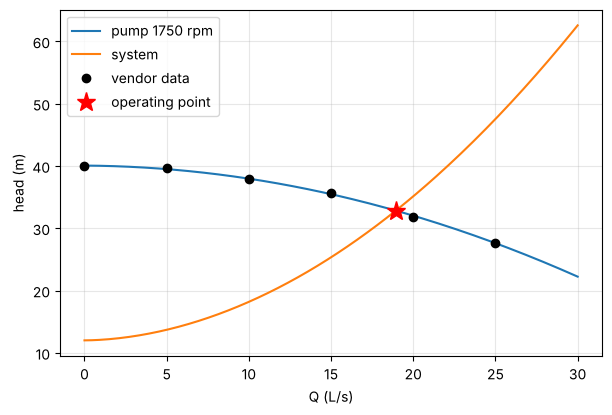

In [2]:
sysc = system_curve(12.0, line())
Q_star, op = operating_point(pump, sysc, return_info=True)
print(f"Q* = {float(Q_star)*1e3:.2f} L/s, H = {float(op['head']):.2f} m, eta = {float(op['efficiency']):.3f}, shaft = {float(op['shaft_power'])/1e3:.2f} kW")

Q = jnp.linspace(0.0, 0.03, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Q*1e3, pump.curve.head(Q), label='pump 1750 rpm')
ax.plot(Q*1e3, jax.vmap(sysc.head)(Q), label='system')
ax.plot(Q_data*1e3, H_data, 'ko', label='vendor data')
ax.plot(float(Q_star)*1e3, float(op['head']), 'r*', ms=14, label='operating point')
ax.set_xlabel('Q (L/s)'); ax.set_ylabel('head (m)'); ax.legend(); ax.grid(alpha=.3)
plt.show()

The unit itself, run at that flow, gives the same head and a discharge pressure:

In [3]:
inlet = make_stream({'W': float(Q_star) * RHO / (MW * 1e-3)}, 293.15, 1.0e5)
outlet, info = pump(inlet)
print('P_out =', float(outlet['P'])/1e5, 'bar')
print({k: round(float(v), 4) for k, v in info.items()})

P_out = 4.213607096961 bar
{'Q': 0.0189, 'head': 32.8288, 'dP': 321360.7097, 'efficiency': 0.718, 'hydraulic_power': 6086.4706, 'shaft_power': 8477.2582, 'electric_power': 8477.2582}


## 2. Affinity laws

Doubling the speed doubles the flow **only** for a pure-friction system. With a static lift the system curve does not scale and the flow does not follow the speed.

no static head, fully rough pipe : Q2/Q1 = 1.2002  (N ratio 1.2)


no static head, smooth-ish pipe  : Q2/Q1 = 1.2058


12 m static head                 : Q2/Q1 = 1.2856


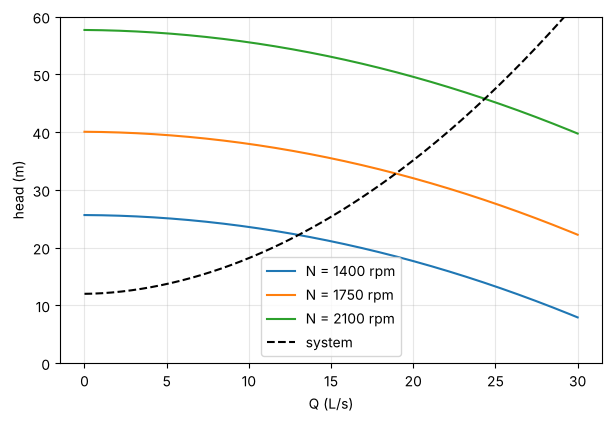

In [4]:
def ratio(system, s=1.2):
    return float(operating_point(PumpCurve(h, speed_ratio=s), system) / operating_point(PumpCurve(h), system))

fully_rough = system_curve(0.0, line(roughness=0.05 * D4))
print('no static head, fully rough pipe : Q2/Q1 =', round(ratio(fully_rough), 4), ' (N ratio 1.2)')
print('no static head, smooth-ish pipe  : Q2/Q1 =', round(ratio(system_curve(0.0, line())), 4))
print('12 m static head                 : Q2/Q1 =', round(ratio(sysc), 4))

fig, ax = plt.subplots(figsize=(7, 4.5))
for s in (0.8, 1.0, 1.2):
    ax.plot(Q*1e3, PumpCurve(h, speed_ratio=s).head(Q), label=f'N = {s*1750:.0f} rpm')
ax.plot(Q*1e3, jax.vmap(sysc.head)(Q), 'k--', label='system')
ax.set_ylim(0, 60); ax.set_xlabel('Q (L/s)'); ax.set_ylabel('head (m)'); ax.legend(); ax.grid(alpha=.3); plt.show()

## 3. Series and parallel

Series adds heads at equal flow, parallel adds flows at equal head. Neither doubles the flow into a system with friction and a static lift.

single 18.94 L/s | series 26.58 L/s | parallel 21.14 L/s


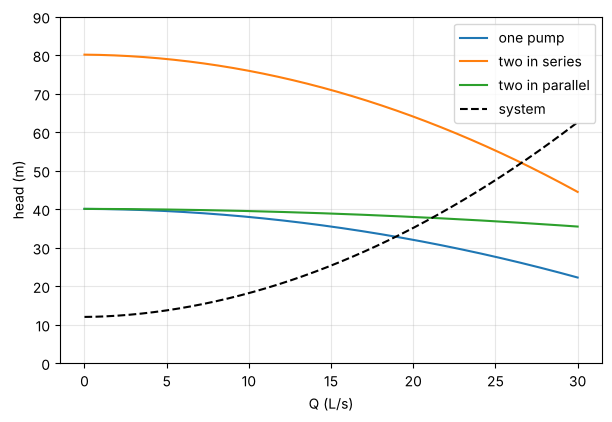

In [5]:
a = PumpCurve(h)
Q1 = float(operating_point(a, sysc))
Qs = float(operating_point(pumps_in_series(a, a), sysc))
Qp = float(operating_point(pumps_in_parallel(a, a), sysc))
print(f'single {Q1*1e3:.2f} L/s | series {Qs*1e3:.2f} L/s | parallel {Qp*1e3:.2f} L/s')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Q*1e3, a.head(Q), label='one pump')
ax.plot(Q*1e3, jax.vmap(pumps_in_series(a, a).head)(Q), label='two in series')
ax.plot(Q*1e3, jax.vmap(pumps_in_parallel(a, a).head)(Q), label='two in parallel')
ax.plot(Q*1e3, jax.vmap(sysc.head)(Q), 'k--', label='system')
ax.set_ylim(0, 90); ax.set_xlabel('Q (L/s)'); ax.set_ylabel('head (m)'); ax.legend(); ax.grid(alpha=.3); plt.show()

## 4. NPSH margin

Cold water has ample margin; 95 C water drawn from an open tank is close to its bubble point (steam-table $P_\mathrm{sat}$ = 84.55 kPa, $\rho$ = 961.9 kg/m3) and NPSHa falls below NPSHr.

In [6]:
def margin(Psat, rho, T, q=0.02):
    p = CentrifugalPump(CentrifugalPumpParams(head_coeffs=h, rho=rho, eta_max=0.72, Q_bep=20e-3,
                        npshr_coeffs=[1.5, 0.0, 2.5e3], N_ref=1750.0, D_ref=0.25, MW=MW, Psat=Psat))
    s = make_stream({'W': q * rho / (MW * 1e-3)}, T, 101325.0)
    return {k: round(float(v), 2) for k, v in p(s)[1].items() if k.startswith('NPSH') or k == 'npsh_margin'}
print('20 C:', margin(2339.0, 998.2, 293.15))
print('95 C:', margin(84550.0, 961.9, 368.15))

20 C: {'NPSHa': 10.11, 'NPSHr': 2.5, 'npsh_margin': 7.61}
95 C: {'NPSHa': 1.78, 'NPSHr': 2.5, 'npsh_margin': -0.72}


## 5. Economic pipe diameter with a VFD-speed constraint

Fixed duty 15 L/s. For each pipe diameter the pump speed is set (VFD) so that the operating point is the duty; the annualised cost is piping + pump capital (`pump_cost`, 20 %/yr charge) + electricity (`pump_electricity_cost`, 8000 h/yr). A small pipe is cheap but needs a fast, power-hungry pump; a large one is the reverse. Because `operating_point` and the speed solve are differentiable, Newton on $\ln D$ uses exact derivatives.

**Cost data.** The $/m piping cost `12 (D/in)^1.1 L` per year is an *illustrative placeholder*. Pump capital and electricity use the library's correlations (`pump_cost` is intended for the library's stated kW range; electricity uses its default utility prices).

optimal D = 85.7 mm, speed = 1930 rpm, cost = 23757 $/yr, |grad| = 3.06e-13


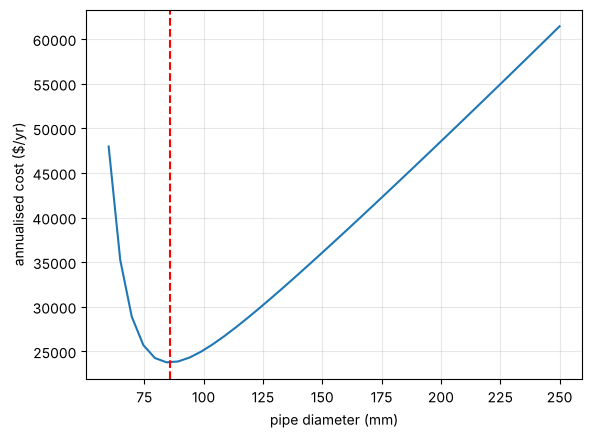

In [7]:
import optimistix as optx
from difflow.economics import pump_cost, pump_electricity_cost

Q_DUTY, ETA_C, L = 0.015, [0, 90.0, -2e3], 400.0     # efficiency curve of the pump (illustrative)

def speed_for_duty(D):
    sy = system_curve(12.0, line(D=D))
    f = lambda s, _: PumpCurve(h, speed_ratio=s).head(Q_DUTY) - sy.head(Q_DUTY)
    return optx.root_find(f, optx.Newton(rtol=1e-12, atol=1e-10), jnp.asarray(1.0)).value

def annual_cost(logD):
    D = jnp.exp(logD)
    cv = PumpCurve(h, ETA_C, speed_ratio=speed_for_duty(D))
    H, eta = cv.head(Q_DUTY), cv.efficiency(Q_DUTY)
    kW = cv.shaft_power(Q_DUTY, RHO) / 1e3
    piping = 12.0 * (D / 0.0254) ** 1.1 * L
    return piping + 0.2 * pump_cost(kW) + 8000 * 3600 * pump_electricity_cost(Q_DUTY, H, eta)

g = jax.jit(jax.grad(annual_cost)); hh = jax.jit(jax.grad(jax.grad(annual_cost)))
x = jnp.log(0.12)
for _ in range(12):
    x = x - g(x) / hh(x)
D_opt = float(jnp.exp(x))
print(f'optimal D = {D_opt*1000:.1f} mm, speed = {float(speed_for_duty(D_opt))*1750:.0f} rpm, '
      f'cost = {float(annual_cost(x)):.0f} $/yr, |grad| = {abs(float(g(x))):.2e}')

Ds = np.linspace(0.06, 0.25, 40)
plt.plot(Ds*1000, [float(annual_cost(jnp.log(d))) for d in Ds]); plt.axvline(D_opt*1000, color='r', ls='--')
plt.xlabel('pipe diameter (mm)'); plt.ylabel('annualised cost ($/yr)'); plt.grid(alpha=.3); plt.show()

In [8]:
# Sensitivity of the operating point to the design variables (implicit-function-theorem gradients)
def Qstar(x):
    sD, sN, sP = x
    return operating_point(PumpCurve(h, speed_ratio=sN, diameter_ratio=sD), system_curve(12.0, line(D=D4 * sP)))
print('dQ*/d[D_imp, N, D_pipe] (m^3/s per unit relative change):', np.asarray(jax.grad(Qstar)(jnp.ones(3))))

dQ*/d[D_imp, N, D_pipe] (m^3/s per unit relative change): [0.02794766 0.02794766 0.03630189]
